# Etapa 1 - Análise exploratória (EDA)

Este notebook carrega a base Bank Marketing, verifica sua qualidade, explora a variável alvo e documenta o tratamento inicial dos dados.

A coluna `duration` é removida na preparação porque representa uma informação conhecida somente depois do contato e causaria vazamento temporal.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'src' / 'utils.py').exists():
            return candidate
    raise FileNotFoundError('Nao foi possivel localizar a raiz do projeto.')

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DATA_FILE
from src.utils import clean_and_prepare_data, load_data, print_data_summary

sns.set_theme(style='whitegrid')
print(f'Raiz do projeto: {PROJECT_ROOT}')
print(f'Arquivo de dados: {DATA_FILE}')

Raiz do projeto: c:\Users\cvmar\OneDrive\Área de Trabalho\datathon-8mlet-grupo-35
Arquivo de dados: c:\Users\cvmar\OneDrive\Área de Trabalho\datathon-8mlet-grupo-35\data\bank-marketing.csv


In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f'Base nao encontrada em {DATA_FILE}. Baixe a base Kaggle Bank Marketing e coloque-a nesse caminho.'
    )

df = load_data(str(DATA_FILE))
print(f'Dimensoes: {df.shape[0]:,} linhas x {df.shape[1]} colunas')
display(df.head())

Dimensoes: 41,188 linhas x 21 colunas


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Qualidade e estrutura dos dados

In [3]:
quality_summary = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'unicos': df.nunique(),
}).sort_values('nulos', ascending=False)

print(f'Duplicatas: {df.duplicated().sum():,}')
display(quality_summary)
display(df.describe(include='all').T)

Duplicatas: 12


,tipo,nulos,unicos
age,int64,0,78
campaign,int64,0,42
nr.employed,float64,0,11
euribor3m,float64,0,316
cons.conf.idx,float64,0,26
cons.price.idx,float64,0,26
emp.var.rate,float64,0,10
poutcome,object,0,3
previous,int64,0,8
pdays,int64,0,27


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41188.0,NaN,NaN,NaN,40.02406,10.42125,17.0,32.0,38.0,47.0,98.0
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Variável alvo e distribuições principais

In [4]:
target_summary = (
    df['y'].value_counts(dropna=False)
    .rename_axis('target')
    .reset_index(name='quantidade')
)
target_summary['proporcao'] = target_summary['quantidade'] / len(df)
display(target_summary)
print(f'Taxa de conversao: {(df["y"] == "yes").mean():.2%}')

,target,quantidade,proporcao
0,no,36548,0.887346
1,yes,4640,0.112654


Taxa de conversao: 11.27%


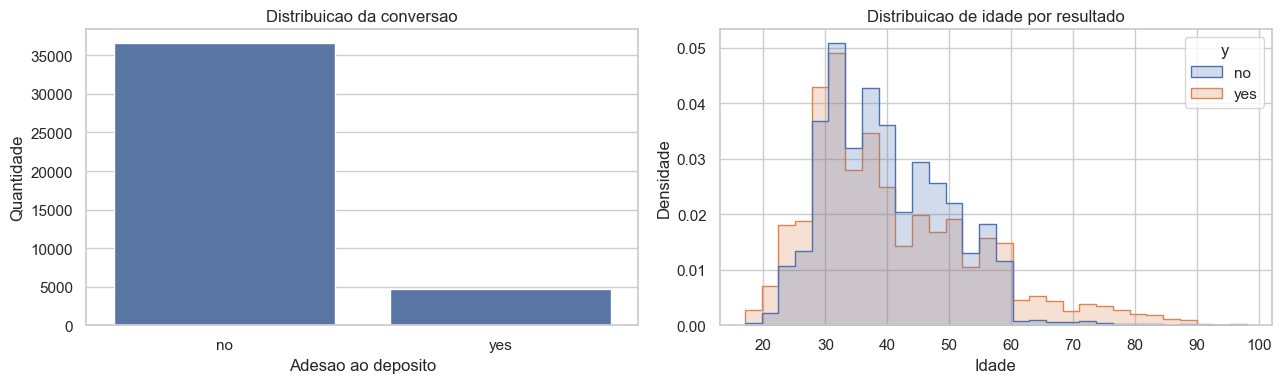

In [5]:
visualizations_dir = PROJECT_ROOT / 'visualizations'
visualizations_dir.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x='y', ax=axes[0], order=['no', 'yes'])
axes[0].set_title('Distribuicao da conversao')
axes[0].set_xlabel('Adesao ao deposito')
axes[0].set_ylabel('Quantidade')

sns.histplot(data=df, x='age', hue='y', bins=30, element='step', stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Distribuicao de idade por resultado')
axes[1].set_xlabel('Idade')
axes[1].set_ylabel('Densidade')

fig.tight_layout()
fig.savefig(visualizations_dir / 'eda_target_age.png', dpi=120, bbox_inches='tight')
plt.show()

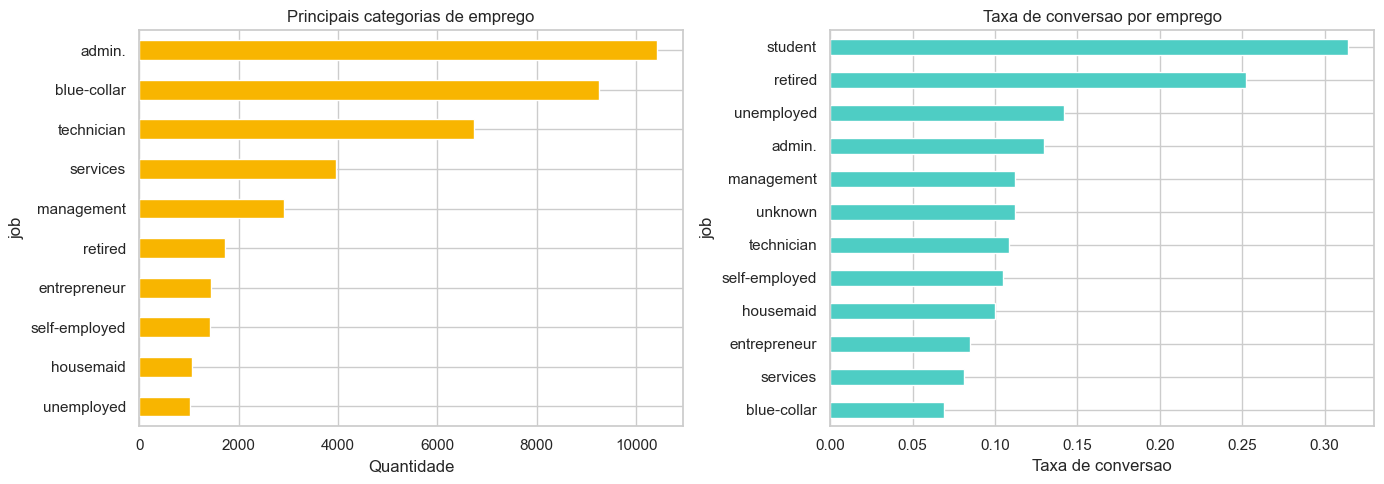

In [6]:
job_counts = df['job'].value_counts().head(10).sort_values()
conversion_by_job = (
    df.assign(converted=(df['y'] == 'yes').astype(int))
    .groupby('job')['converted']
    .mean()
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
job_counts.plot.barh(ax=axes[0], color='#F8B500')
axes[0].set_title('Principais categorias de emprego')
axes[0].set_xlabel('Quantidade')

conversion_by_job.plot.barh(ax=axes[1], color='#4ECDC4')
axes[1].set_title('Taxa de conversao por emprego')
axes[1].set_xlabel('Taxa de conversao')

fig.tight_layout()
fig.savefig(visualizations_dir / 'eda_job_conversion.png', dpi=120, bbox_inches='tight')
plt.show()

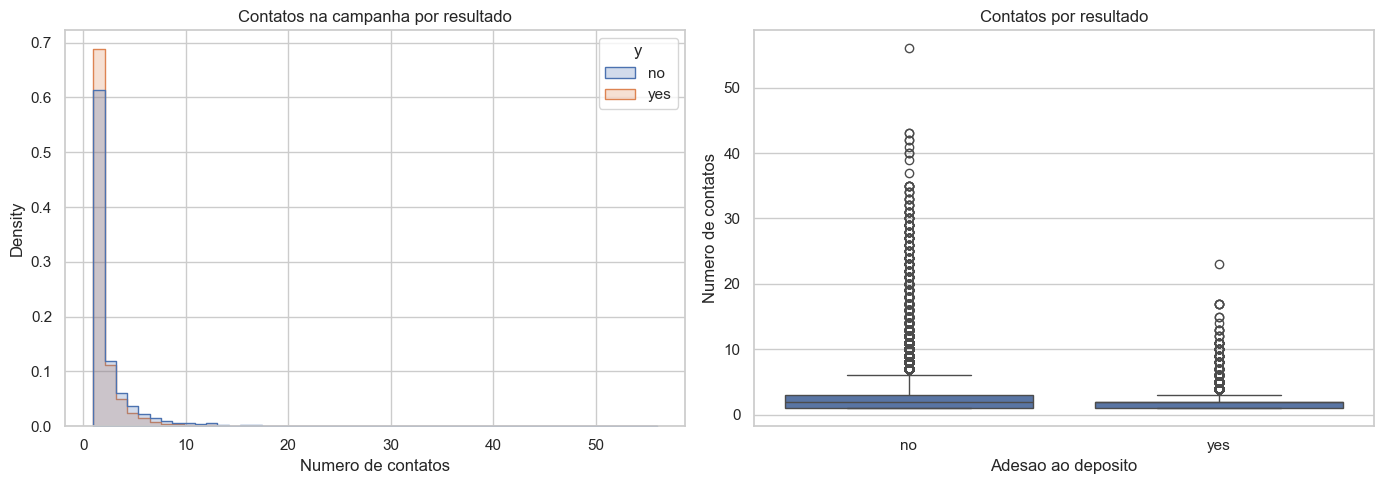

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='campaign', hue='y', bins=50, element='step', stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Contatos na campanha por resultado')
axes[0].set_xlabel('Numero de contatos')

sns.boxplot(data=df, x='y', y='campaign', order=['no', 'yes'], ax=axes[1])
axes[1].set_title('Contatos por resultado')
axes[1].set_xlabel('Adesao ao deposito')
axes[1].set_ylabel('Numero de contatos')

fig.tight_layout()
fig.savefig(visualizations_dir / 'eda_campaign.png', dpi=120, bbox_inches='tight')
plt.show()

## Tratamento inicial

A função compartilhada do projeto remove duplicatas, descarta linhas com valores ausentes e exclui `duration`. A codificação e a normalização para o modelo são executadas no notebook da Etapa 2.

In [8]:
df_clean = clean_and_prepare_data(df, drop_duration=True)
removed_columns = sorted(set(df.columns) - set(df_clean.columns))

print(f'Linhas antes: {len(df):,}')
print(f'Linhas depois: {len(df_clean):,}')
print(f'Colunas removidas: {removed_columns}')
print(f'Coluna duration presente apos o tratamento? {"duration" in df_clean.columns}')
display(df_clean.head())
print_data_summary(df_clean)

Linhas antes: 41,188
Linhas depois: 39,404
Colunas removidas: ['duration']
Coluna duration presente apos o tratamento? False


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Conclusões da EDA

- A variável `y` é binária e apresenta desbalanceamento, portanto a taxa de conversão deve ser reportada explicitamente.
- As variáveis de cliente e de campanha estão disponíveis antes da decisão e podem compor o contexto.
- `duration` foi removida para evitar vazamento temporal.
- A preparação final, a comparação com o baseline e o Thompson Sampling estão no notebook `02_modelo.ipynb`.